In [29]:
#importando as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

In [30]:
#Leitura da planilha
arquivo = "Dados Habitacionais de Ames.xlsx"

df = pd.read_excel(arquivo)
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


**Criando o Data Frame**

In [31]:
df2 = df['SalePrice']
df2

,SalePrice
0,215000
1,105000
2,172000
3,244000
4,189900
...,...
2925,142500
2926,131000
2927,132000
2928,170000


##Variável 1: Sale Price

Quartil 1

In [32]:
Q1 = df.SalePrice.quantile(q=0.25)
Q1

np.float64(129500.0)

Quartil 2 | Mediana

In [33]:
Q2 = df.SalePrice.quantile(q=0.5)
Q2

np.float64(160000.0)

Quartil 3

In [34]:
Q3 = df.SalePrice.quantile(q=0.75)
Q3

np.float64(213500.0)

Describe do Sale Price

In [35]:
df.SalePrice.describe().round(2)

,SalePrice
count,2930.00
mean,180796.06
std,79886.69
min,12789.00
25%,129500.00
50%,160000.00
75%,213500.00
max,755000.00


Boxplot

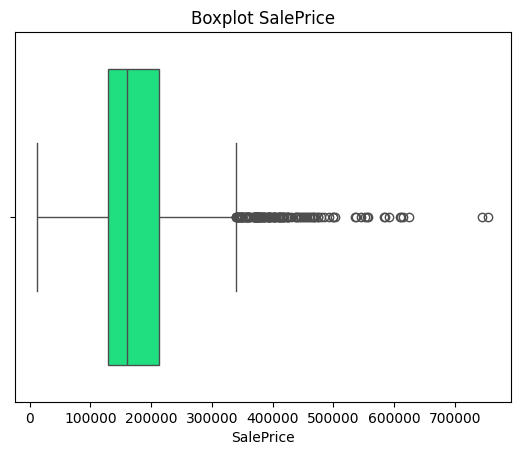

In [36]:
sns.boxplot(df.SalePrice, orient='h', color=[0,1,0.5])
plt.title('Boxplot SalePrice')
plt.show()


Amplitude interquartil

In [37]:
AIQ =Q3-Q1
AIQ

np.float64(84000.0)

Limite Inferior & Limite superior

In [38]:
linf = Q1 - 1.5*AIQ
lsup = Q3 + 1.5*AIQ
print("linf =", linf)
print("lsup =", lsup)

linf = 3500.0
lsup = 339500.0


Visualização de Outliers Superiores

In [39]:
df[df.SalePrice>lsup]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
15,16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
17,18,527258010,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
36,37,528108120,60,RL,102.0,12858,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,New,Partial,376162
38,39,528120060,20,RL,83.0,10159,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,New,Partial,395192
44,45,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2666,2667,902400110,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
2737,2738,905427030,75,RL,60.0,19800,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,415000
2883,2884,911370430,120,RM,41.0,5748,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,2,2006,New,Partial,375000
2901,2902,921205030,20,RL,88.0,11443,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2006,New,Partial,369900


Visualização de Outliers Inferiores

In [40]:
df[df.SalePrice<linf]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


Boxplot Sem os Outliers

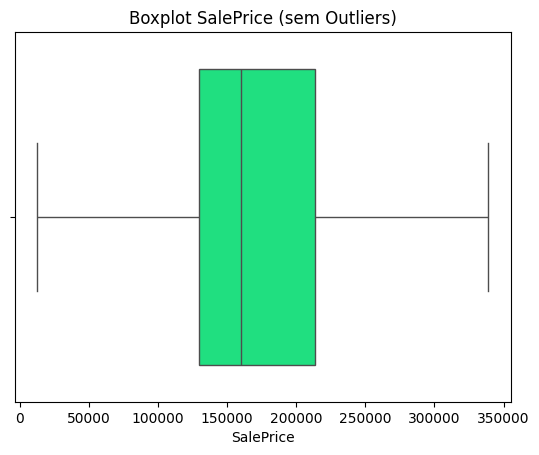

In [41]:
sns.boxplot(df.SalePrice, orient='h', color=[0,1,0.5], showfliers=False)
plt.title('Boxplot SalePrice (sem Outliers)')
plt.show()

### Desvio Padrão

**Desvio Padrão Amostral**

In [42]:
df2.std()

79886.69235666493

**Desvio Padrão Populacional**

In [43]:
df2.std(ddof=0)

79873.05865192247

### Coeficiente de Variação

**Coeficiente de Variação Amostral**

In [44]:
scipy.stats.variation(df2,ddof=1)*100

np.float64(44.186080341852495)

**Coeficiente de Variação Populacional**

In [45]:
scipy.stats.variation(df2,ddof=0)*100

np.float64(44.17853941162574)

Interpretação do Boxplot

A análise do Boxplot da variável `SalePrice` revela importantes características da distribuição dos preços de venda:

*   **Limites Interquartis:** O conjunto de dados apresenta um limite inferior de 3.500,0 USD e um limite superior de 339.500,0 USD.
*   **Outliers Superiores:** Foram identificados 137 dados que se classificam como outliers superiores, indicando preços de venda significativamente mais altos que a maioria.
*   **Outliers Inferiores:** Não foram encontrados outliers inferiores, sugerindo que não há preços de venda atipicamente baixos em relação à distribuição geral.